# AI Visual Novel — Exploratory Data Analysis (EDA)

Systematic exploration of three data sources:
1. **`game_design.json`** — Story graph structure, characters, scenes
2. **`story.txt`** — Script content, dialogue distribution, expressions
3. **`RAG knowledge base`** — Wikipedia corpus statistics

In [1]:
import json
import re
import os
import sys
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import networkx as nx

# ── Path setup ──────────────────────────────────────────────────────────────
ROOT = Path(__file__).parent.parent if "__file__" in dir() else Path("..").resolve()
DESIGN_PATH   = ROOT / "data" / "game_design.json"
STORY_PATH    = ROOT / "data" / "story.txt"
RAG_DIR       = ROOT / "data" / "rag"
EXPR_PATH     = ROOT / "data" / "character_expressions.json"

# ── Style ────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
# Use a font that supports CJK characters if available
import matplotlib.font_manager as fm
cjk_fonts = [f.name for f in fm.fontManager.ttflist if "Han" in f.name or "Heiti" in f.name or "PingFang" in f.name]
if cjk_fonts:
    plt.rcParams["font.family"] = cjk_fonts[0]
else:
    plt.rcParams["font.family"] = "DejaVu Sans"

PALETTE = sns.color_palette("Set2", 10)
print("✅ Environment ready")
print(f"   ROOT       : {ROOT}")
print(f"   design.json: {DESIGN_PATH.exists()}")
print(f"   story.txt  : {STORY_PATH.exists()}")
print(f"   RAG dir    : {RAG_DIR.exists()}")

✅ Environment ready
   ROOT       : /Users/rolan/cmu/Data Science/AI4VisualNovel
   design.json: True
   story.txt  : True
   RAG dir    : True


---
## Part 1 — EDA on `game_design.json`

Analysing story graph topology, character settings and scene information.

In [2]:
# ── Load game_design.json ────────────────────────────────────────────────────
with open(DESIGN_PATH, encoding="utf-8") as f:
    design = json.load(f)

nodes   = design["story_graph"]["nodes"]      # {node_id: node_dict}
edges   = design["story_graph"]["edges"]      # [{"from":..,"to":..,"choice_text":..}]
chars   = design["characters"]
scenes  = design["scenes"]

# ── Build NetworkX DiGraph ────────────────────────────────────────────────────
G = nx.DiGraph()
for nid, ndata in nodes.items():
    G.add_node(nid, node_type=ndata.get("type", "normal"))
for e in edges:
    G.add_edge(e["from"], e["to"], choice=e.get("choice_text") or "")

# ── Basic statistics ──────────────────────────────────────────────────────────
num_nodes    = G.number_of_nodes()
num_edges    = G.number_of_edges()
out_degrees  = dict(G.out_degree())
in_degrees   = dict(G.in_degree())
avg_out_deg  = np.mean(list(out_degrees.values()))

node_types   = Counter(ndata.get("type","normal") for ndata in nodes.values())
endings      = [n for n, d in nodes.items() if d.get("type") == "ending"]
merge_nodes  = [n for n, d in nodes.items() if d.get("type") == "merge"]
choice_nodes = [n for n in nodes if out_degrees.get(n, 0) > 1]

# All root→ending paths via DFS
def all_paths(G, source, sinks):
    results = []
    def dfs(node, path, visited):
        if node in sinks:
            results.append(list(path)); return
        for nxt in G.successors(node):
            if nxt not in visited:
                path.append(nxt); visited.add(nxt)
                dfs(nxt, path, visited)
                path.pop(); visited.discard(nxt)
    dfs(source, [source], {source})
    return results

root = "root"
sink_set = set(endings)
paths = all_paths(G, root, sink_set)
path_lengths = [len(p) for p in paths]

print("=" * 50)
print(f"  Title          : {design['title']}")
print(f"  Nodes          : {num_nodes}")
print(f"  Edges          : {num_edges}")
print(f"  Characters     : {len(chars)}")
print(f"  Scenes         : {len(scenes)}")
print(f"  Endings        : {len(endings)}  {endings}")
print(f"  Merge nodes    : {len(merge_nodes)}  {merge_nodes}")
print(f"  Choice nodes   : {len(choice_nodes)}  {choice_nodes}")
print(f"  Avg out-degree : {avg_out_deg:.2f}")
print(f"  Total paths    : {len(paths)}")
print(f"  Path lengths   : min={min(path_lengths)}, max={max(path_lengths)}, mean={np.mean(path_lengths):.1f}")
print(f"  Merge node %   : {len(merge_nodes)/num_nodes*100:.1f}%")
print("=" * 50)

  Title          : 链锯人的耳语：回响之所
  Nodes          : 13
  Edges          : 14
  Characters     : 4
  Scenes         : 8
  Endings        : 2  ['ending1', 'ending2']
  Merge nodes    : 2  ['node5', 'node8']
  Choice nodes   : 3  ['node2', 'node5', 'node8']
  Avg out-degree : 1.08
  Total paths    : 8
  Path lengths   : min=9, max=9, mean=9.0
  Merge node %   : 15.4%


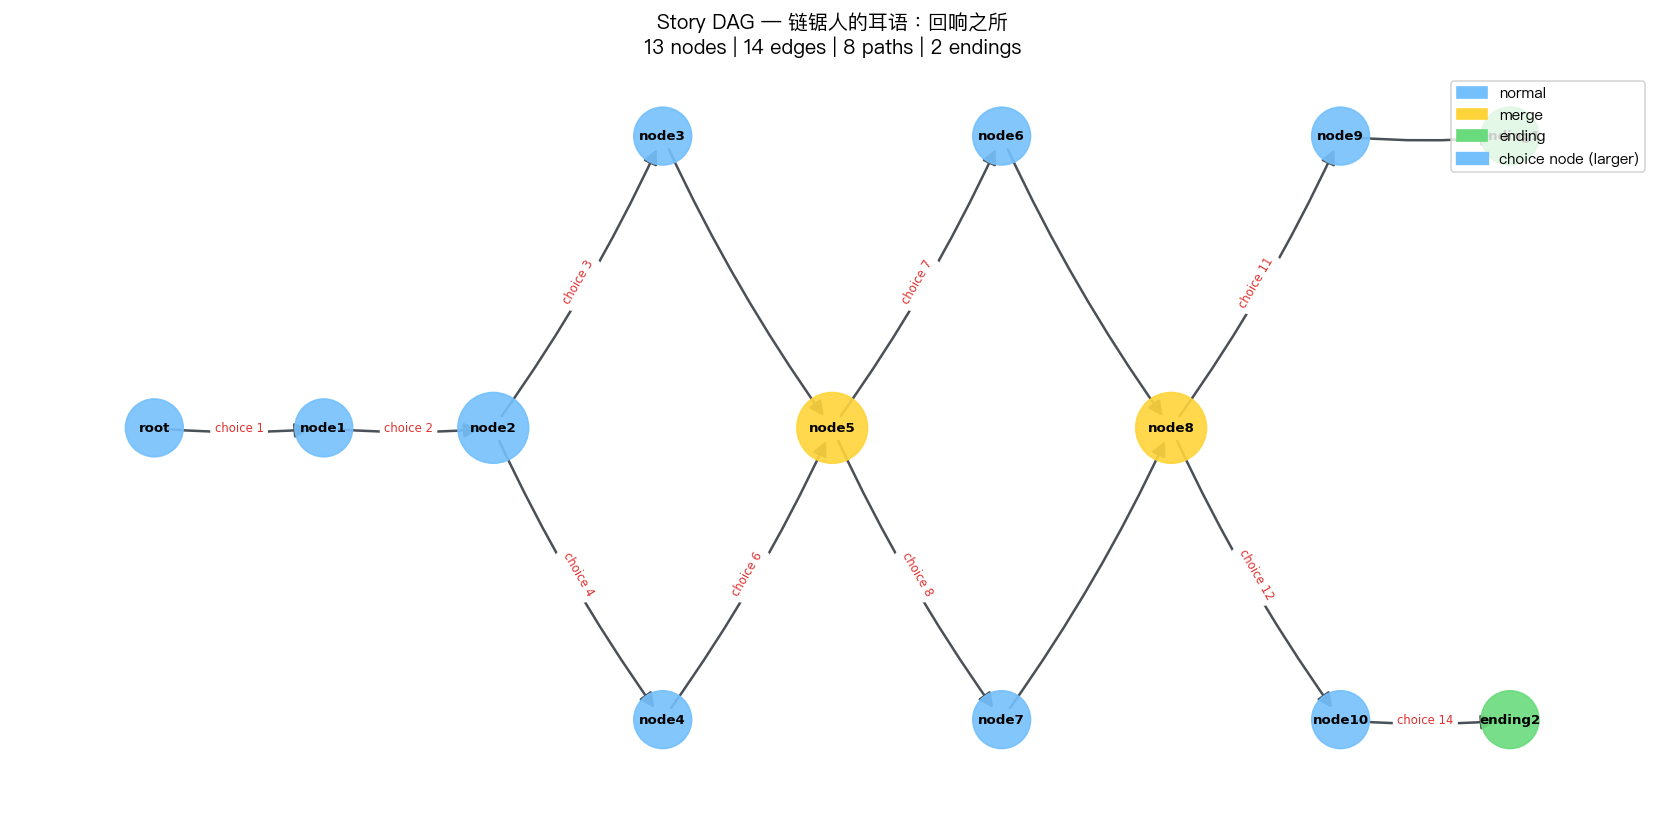

Saved: eval/fig1_dag.png


In [ ]:
# ── Fig 1: DAG Structure Visualization ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))

# Hierarchical layout using topological generations
try:
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot")
except Exception:
    # Fallback: manual layered layout
    topo = list(nx.topological_sort(G))
    layers = {}
    for n in topo:
        preds = list(G.predecessors(n))
        layers[n] = max((layers.get(p, 0) for p in preds), default=-1) + 1
    layer_members = defaultdict(list)
    for n, l in layers.items():
        layer_members[l].append(n)
    pos = {}
    for l, members in sorted(layer_members.items()):
        for i, n in enumerate(members):
            pos[n] = (l * 2, -(i - len(members) / 2))

# Color by node type
color_map = {"normal": "#74C0FC", "merge": "#FFD43B", "ending": "#69DB7C"}
node_colors = [color_map.get(nodes[n].get("type", "normal"), "#ADB5BD") for n in G.nodes()]
node_sizes  = [1800 if n in choice_nodes else 1200 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowsize=18,
                       edge_color="#495057", width=1.5,
                       connectionstyle="arc3,rad=0.05")

# Edge labels (choice text, truncated)
edge_labels = {(e["from"], e["to"]): (e.get("choice_text") or "")[:8]
               for e in edges if e.get("choice_text")}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=7,
                              font_color="#E03131", ax=ax)

# Legend
legend_handles = [mpatches.Patch(color=c, label=t) for t, c in color_map.items()]
legend_handles.append(mpatches.Patch(color="#74C0FC", label="choice node (larger)", linewidth=2))
ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
ax.set_title(f"Story DAG — {design['title']}\n"
             f"{num_nodes} nodes | {num_edges} edges | {len(paths)} paths | {len(endings)} endings",
             fontsize=12, pad=12)
ax.axis("off")
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig1_dag.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig1_dag.png")

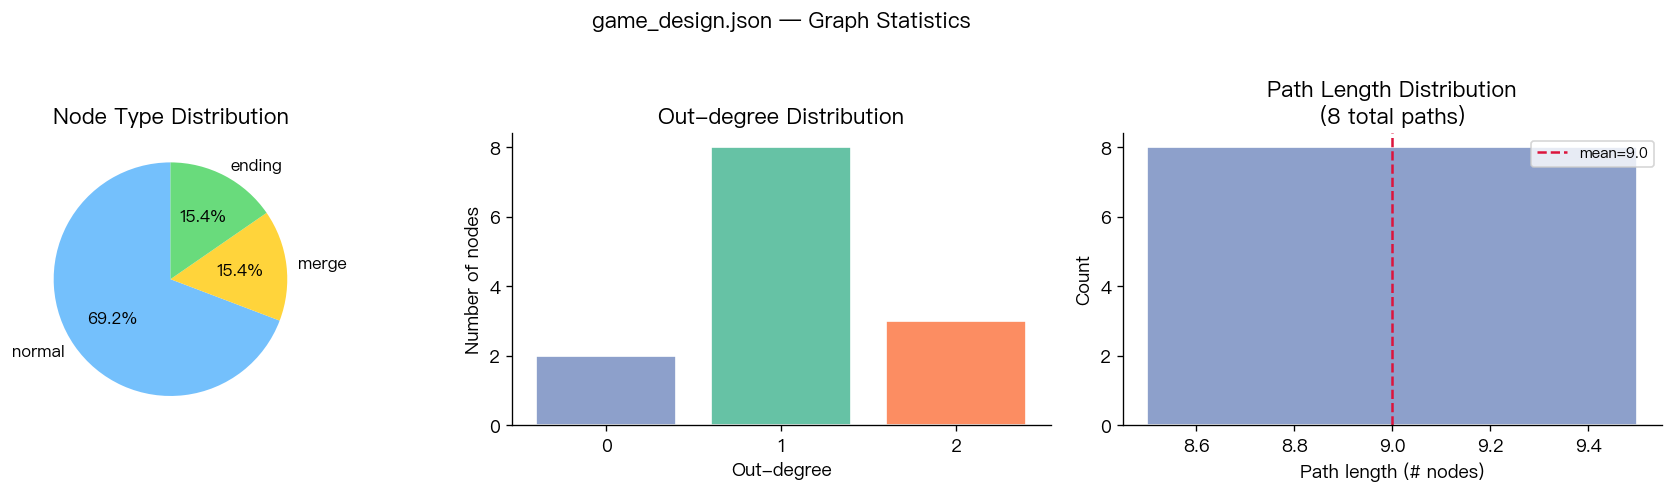

Saved: eval/fig2_graph_stats.png


In [4]:
# ── Fig 2: Node-type distribution + path-length histogram ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 2a: Node type pie
type_counts = Counter(ndata.get("type", "normal") for ndata in nodes.values())
axes[0].pie(type_counts.values(), labels=type_counts.keys(),
            colors=[color_map.get(t, "#ADB5BD") for t in type_counts.keys()],
            autopct="%1.1f%%", startangle=90, textprops={"fontsize": 10})
axes[0].set_title("Node Type Distribution")

# 2b: Out-degree bar
od_counter = Counter(out_degrees.values())
axes[1].bar(od_counter.keys(), od_counter.values(),
            color=PALETTE[:len(od_counter)], edgecolor="white")
axes[1].set_xlabel("Out-degree")
axes[1].set_ylabel("Number of nodes")
axes[1].set_title("Out-degree Distribution")
axes[1].set_xticks(sorted(od_counter.keys()))

# 2c: Path length histogram
axes[2].hist(path_lengths, bins=range(min(path_lengths), max(path_lengths)+2),
             color=PALETTE[2], edgecolor="white", align="left")
axes[2].set_xlabel("Path length (# nodes)")
axes[2].set_ylabel("Count")
axes[2].set_title(f"Path Length Distribution\n({len(paths)} total paths)")
axes[2].axvline(np.mean(path_lengths), color="crimson", linestyle="--",
                label=f"mean={np.mean(path_lengths):.1f}")
axes[2].legend(fontsize=9)

plt.suptitle("game_design.json — Graph Statistics", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig2_graph_stats.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig2_graph_stats.png")

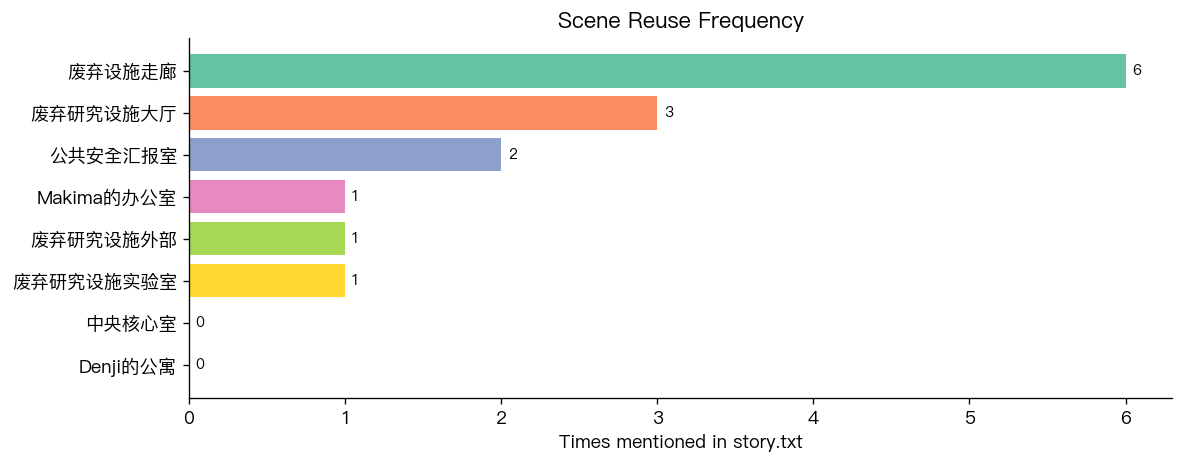

Scene reuse stats: max=6, min=0, mean=1.8
Saved: eval/fig3_scene_reuse.png


In [5]:
# ── Scene reuse analysis ──────────────────────────────────────────────────────
with open(STORY_PATH, encoding="utf-8") as f:
    story_raw = f.read()

# Count how many times each scene name appears in story.txt
scene_names = [s["name"] for s in scenes]
scene_usage = {name: len(re.findall(re.escape(name), story_raw)) for name in scene_names}

fig, ax = plt.subplots(figsize=(10, 4))
sorted_scenes = sorted(scene_usage.items(), key=lambda x: -x[1])
names_s, counts_s = zip(*sorted_scenes)
bars = ax.barh(names_s, counts_s, color=PALETTE[:len(names_s)])
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_xlabel("Times mentioned in story.txt")
ax.set_title("Scene Reuse Frequency")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig3_scene_reuse.png", dpi=130, bbox_inches="tight")
plt.show()
print(f"Scene reuse stats: max={max(counts_s)}, min={min(counts_s)}, mean={np.mean(counts_s):.1f}")
print("Saved: eval/fig3_scene_reuse.png")

---
## Part 2 — EDA on `story.txt`

Analysing dialogue distribution, per-character statistics, expressions and scene switches.

In [6]:
# ── Parse story.txt ──────────────────────────────────────────────────────────
node_blocks = {}   # {node_id: text_block}
current_node = None
current_lines = []

for line in story_raw.split("\n"):
    m = re.match(r"=== Node: (\w+) ===", line)
    if m:
        if current_node:
            node_blocks[current_node] = "\n".join(current_lines)
        current_node = m.group(1)
        current_lines = []
    else:
        if current_node:
            current_lines.append(line)
if current_node:
    node_blocks[current_node] = "\n".join(current_lines)

# ── Per-node text length ──────────────────────────────────────────────────────
node_lengths = {nid: len(text) for nid, text in node_blocks.items()}

# ── Dialogue parsing ──────────────────────────────────────────────────────────
# <content id="CharName">text</content>
dialogue_pattern = re.compile(r'<content id="([^"]+)">(.*?)</content>', re.DOTALL)
all_dialogues = dialogue_pattern.findall(story_raw)    # [(speaker, text), ...]

speaker_lines  = Counter(sp for sp, _ in all_dialogues)
speaker_chars  = Counter()
for sp, txt in all_dialogues:
    speaker_chars[sp] += len(txt.strip())

# ── Expression tags ───────────────────────────────────────────────────────────
expr_pattern = re.compile(r'<image id="([^"]+)">(\w+)</image>')
all_exprs = expr_pattern.findall(story_raw)   # [(char, expression), ...]
expr_counter    = Counter(expr for _, expr in all_exprs)
char_expr_counter = Counter(f"{c}:{e}" for c, e in all_exprs)

# ── Scene tags ────────────────────────────────────────────────────────────────
scene_tags = re.findall(r'<scene>([^<]+)</scene>', story_raw)
scene_switches = Counter(scene_tags)

# ── Narration vs dialogue ─────────────────────────────────────────────────────
narration_lines = speaker_lines.get("旁白", 0)
dialogue_lines  = sum(v for k, v in speaker_lines.items() if k != "旁白")

print(f"Total nodes in story: {len(node_blocks)}")
print(f"Total dialogue lines : {sum(speaker_lines.values())}")
print(f"  Narration (旁白)   : {narration_lines}")
print(f"  Character dialogue : {dialogue_lines}")
print(f"  Narration ratio    : {narration_lines/(narration_lines+dialogue_lines)*100:.1f}%")
print(f"\nPer-speaker line counts:")
for sp, cnt in speaker_lines.most_common():
    chars_cnt = speaker_chars[sp]
    print(f"  {sp:20s}  lines={cnt:4d}  chars={chars_cnt:6d}")
print(f"\nExpression tag total : {len(all_exprs)}")
print(f"Expression types     : {dict(expr_counter.most_common(8))}")
print(f"\nScene switch total   : {len(scene_tags)}")
print(f"Unique scenes used   : {len(scene_switches)}")

Total nodes in story: 13
Total dialogue lines : 384
  Narration (旁白)   : 132
  Character dialogue : 252
  Narration ratio    : 34.4%

Per-speaker line counts:
  Aki Hayakawa          lines= 143  chars=  2129
  旁白                    lines= 132  chars=  6174
  我                     lines=  49  chars=   593
  Power                 lines=  33  chars=   539
  Makima                lines=  27  chars=   465

Expression tag total : 196
Expression types     : {'serious': 77, 'neutral': 25, 'annoyed': 24, 'puzzled': 23, 'excited': 19, 'pensive': 11, 'smirking': 6, 'repulsed': 4}

Scene switch total   : 14
Unique scenes used   : 6


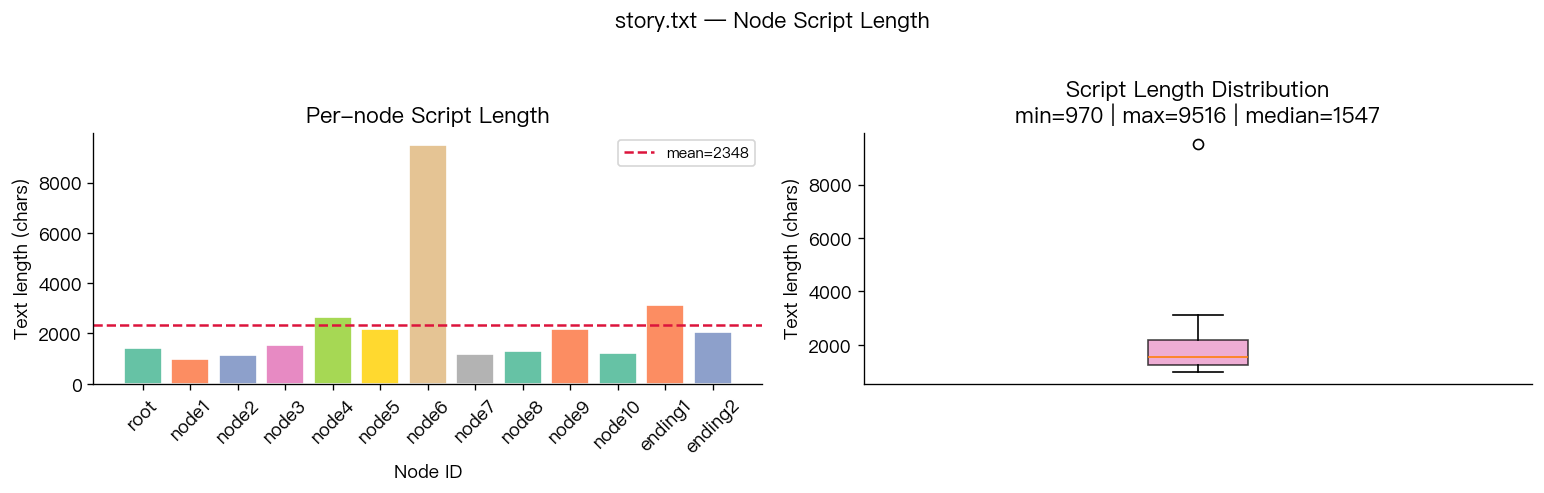

Saved: eval/fig4_node_lengths.png


In [7]:
# ── Fig 4: Node text-length histogram ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

lengths_vals = list(node_lengths.values())
axes[0].bar(node_lengths.keys(), lengths_vals,
            color=[PALETTE[i % len(PALETTE)] for i in range(len(node_lengths))],
            edgecolor="white")
axes[0].set_xlabel("Node ID")
axes[0].set_ylabel("Text length (chars)")
axes[0].set_title("Per-node Script Length")
axes[0].tick_params(axis="x", rotation=45)
axes[0].axhline(np.mean(lengths_vals), color="crimson", linestyle="--",
                label=f"mean={np.mean(lengths_vals):.0f}")
axes[0].legend(fontsize=9)

# Box plot of lengths
axes[1].boxplot(lengths_vals, vert=True, patch_artist=True,
                boxprops=dict(facecolor=PALETTE[3], alpha=0.7))
axes[1].set_ylabel("Text length (chars)")
axes[1].set_title(f"Script Length Distribution\nmin={min(lengths_vals)} | max={max(lengths_vals)} | median={int(np.median(lengths_vals))}")
axes[1].set_xticks([])

plt.suptitle("story.txt — Node Script Length", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig4_node_lengths.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig4_node_lengths.png")

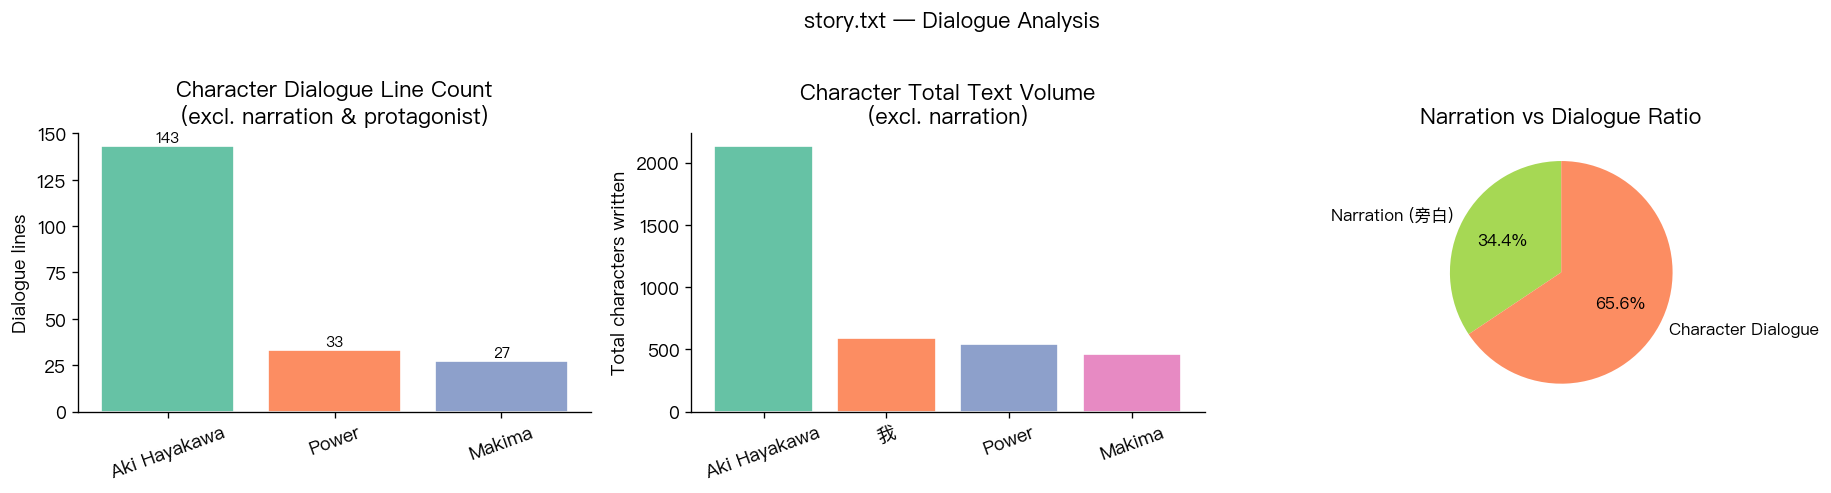

Saved: eval/fig5_dialogue.png


In [8]:
# ── Fig 5: Character dialogue bar chart + narration pie ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 5a: Line count bar
char_speakers = {k: v for k, v in speaker_lines.items() if k != "旁白" and k != "我"}
sorted_chars = sorted(char_speakers.items(), key=lambda x: -x[1])
names_c, lines_c = zip(*sorted_chars) if sorted_chars else ([], [])

axes[0].bar(names_c, lines_c,
            color=PALETTE[:len(names_c)], edgecolor="white")
axes[0].set_ylabel("Dialogue lines")
axes[0].set_title("Character Dialogue Line Count\n(excl. narration & protagonist)")
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(lines_c):
    axes[0].text(i, v + 0.5, str(v), ha="center", va="bottom", fontsize=9)

# 5b: Total character count bar (including protagonist "我")
sorted_chars_all = sorted(
    {k: v for k, v in speaker_chars.items() if k != "旁白"}.items(),
    key=lambda x: -x[1]
)
names_a, chars_a = zip(*sorted_chars_all) if sorted_chars_all else ([], [])
axes[1].bar(names_a, chars_a,
            color=PALETTE[:len(names_a)], edgecolor="white")
axes[1].set_ylabel("Total characters written")
axes[1].set_title("Character Total Text Volume\n(excl. narration)")
axes[1].tick_params(axis="x", rotation=20)

# 5c: Narration vs dialogue pie
pie_labels = ["Narration (旁白)", "Character Dialogue"]
pie_values = [narration_lines, dialogue_lines]
axes[2].pie(pie_values, labels=pie_labels, autopct="%1.1f%%",
            colors=[PALETTE[4], PALETTE[1]], startangle=90,
            textprops={"fontsize": 10})
axes[2].set_title("Narration vs Dialogue Ratio")

plt.suptitle("story.txt — Dialogue Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig5_dialogue.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig5_dialogue.png")

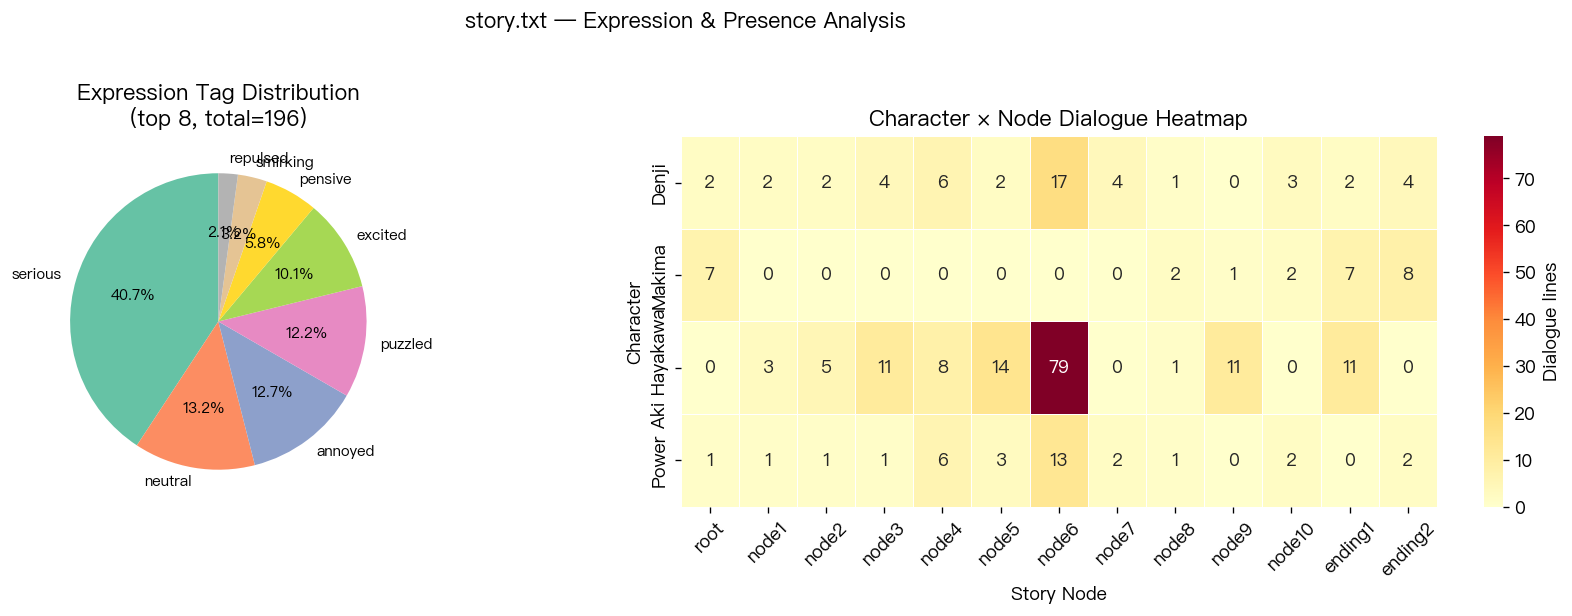

Saved: eval/fig6_expr_heatmap.png


In [9]:
# ── Fig 6: Expression pie + heatmap (character × node) ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 6a: Expression type pie
top_exprs = expr_counter.most_common(8)
e_labels, e_vals = zip(*top_exprs) if top_exprs else ([], [])
axes[0].pie(e_vals, labels=e_labels, autopct="%1.1f%%",
            colors=PALETTE[:len(e_labels)], startangle=90,
            textprops={"fontsize": 9})
axes[0].set_title(f"Expression Tag Distribution\n(top {len(e_labels)}, total={sum(expr_counter.values())})")

# 6b: Character × node appearance heatmap
char_names_hm = [c["name"] for c in chars]
node_ids_hm   = list(node_blocks.keys())

# Count dialogue lines per (character, node)
matrix = np.zeros((len(char_names_hm), len(node_ids_hm)), dtype=int)
for nid, block in node_blocks.items():
    if nid not in node_ids_hm:
        continue
    j = node_ids_hm.index(nid)
    for sp, txt in dialogue_pattern.findall(block):
        # Map protagonist "我" → first protagonist character
        mapped_sp = sp
        if sp == "我":
            for c in chars:
                if c.get("is_protagonist"):
                    mapped_sp = c["name"]; break
        if mapped_sp in char_names_hm:
            i = char_names_hm.index(mapped_sp)
            matrix[i][j] += 1

sns.heatmap(matrix, ax=axes[1],
            xticklabels=node_ids_hm, yticklabels=char_names_hm,
            cmap="YlOrRd", annot=True, fmt="d", linewidths=0.4,
            cbar_kws={"label": "Dialogue lines"})
axes[1].set_title("Character × Node Dialogue Heatmap")
axes[1].set_xlabel("Story Node")
axes[1].set_ylabel("Character")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("story.txt — Expression & Presence Analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig6_expr_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig6_expr_heatmap.png")

---
## Part 3 — EDA on RAG Knowledge Base

Analysing corpus composition: document counts, source types, character coverage.

In [10]:
# ── Load all RAG JSON files ───────────────────────────────────────────────────
rag_files = list(RAG_DIR.glob("knowledge_*.json"))
all_docs   = []
ip_doc_counts = {}

for fp in rag_files:
    with open(fp, encoding="utf-8") as f:
        data = json.load(f)
    docs = data.get("documents", [])
    ip_name = fp.stem.replace("knowledge_", "").replace("_", " ")
    ip_doc_counts[ip_name] = len(docs)
    all_docs.extend(docs)

total_docs = len(all_docs)

# ── Type breakdown ─────────────────────────────────────────────────────────────
source_counter   = Counter(d["metadata"].get("source", "unknown") for d in all_docs)
type_counter     = Counter(d["metadata"].get("type",   "unknown") for d in all_docs)

# ── Per-character doc counts ──────────────────────────────────────────────────
char_doc_counts = Counter()
for d in all_docs:
    char = d["metadata"].get("character") or d["metadata"].get("title", "franchise")
    char_doc_counts[char] += 1

# ── Document text length stats ────────────────────────────────────────────────
doc_lengths = [len(d["text"]) for d in all_docs]

print(f"RAG files found    : {len(rag_files)}  {[f.name for f in rag_files]}")
print(f"Total documents    : {total_docs}")
print(f"\nSource breakdown   : {dict(source_counter)}")
print(f"Type breakdown     : {dict(type_counter)}")
print(f"\nPer-character/title doc counts:")
for k, v in char_doc_counts.most_common():
    print(f"  {k:35s}: {v}")
print(f"\nDoc text length    : min={min(doc_lengths)} | max={max(doc_lengths)} | mean={np.mean(doc_lengths):.0f}")

RAG files found    : 1  ['knowledge_ChainSaw_Man.json']
Total documents    : 27

Source breakdown   : {'wikipedia': 27}
Type breakdown     : {'franchise': 2, 'character': 25}

Per-character/title doc counts:
  Aki Hayakawa                       : 8
  Denji                              : 6
  Makima                             : 6
  Power                              : 5
  Chainsaw Man                       : 2

Doc text length    : min=116 | max=2629 | mean=1343


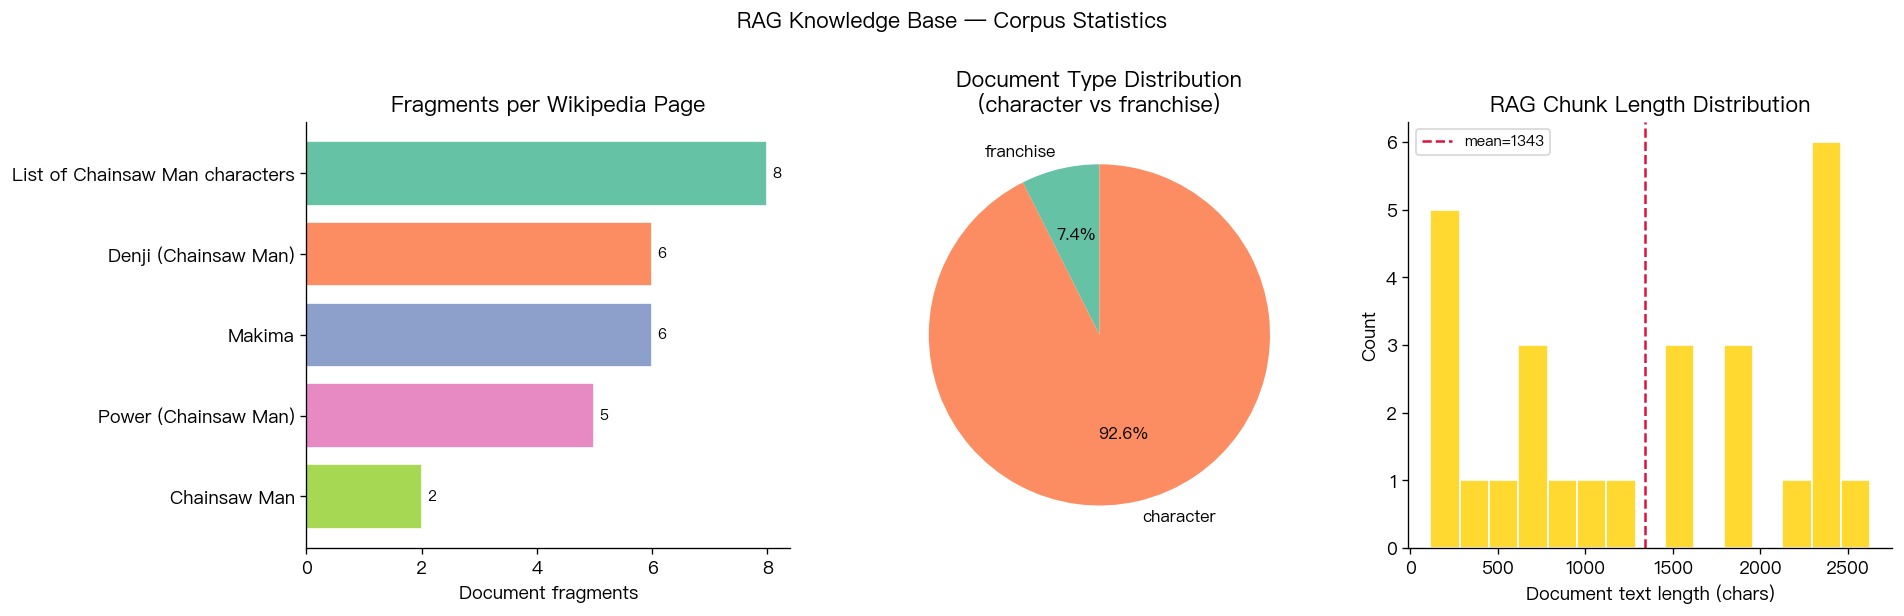

Saved: eval/fig7_rag_corpus.png


In [11]:
# ── Fig 7: RAG corpus breakdown charts ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a: Docs per Wikipedia title (bar)
title_counts = Counter(
    d["metadata"].get("title", "unknown") for d in all_docs
)
sorted_titles = title_counts.most_common()
t_labels, t_vals = zip(*sorted_titles) if sorted_titles else ([], [])
bars7a = axes[0].barh(t_labels, t_vals,
                      color=PALETTE[:len(t_labels)], edgecolor="white")
axes[0].bar_label(bars7a, padding=3, fontsize=9)
axes[0].set_xlabel("Document fragments")
axes[0].set_title("Fragments per Wikipedia Page")
axes[0].invert_yaxis()

# 7b: character vs franchise type pie
type_labels = list(type_counter.keys())
type_vals   = list(type_counter.values())
axes[1].pie(type_vals, labels=type_labels, autopct="%1.1f%%",
            colors=PALETTE[:len(type_labels)], startangle=90,
            textprops={"fontsize": 10})
axes[1].set_title("Document Type Distribution\n(character vs franchise)")

# 7c: Doc text length histogram
axes[2].hist(doc_lengths, bins=15, color=PALETTE[5], edgecolor="white")
axes[2].axvline(np.mean(doc_lengths), color="crimson", linestyle="--",
                label=f"mean={np.mean(doc_lengths):.0f}")
axes[2].set_xlabel("Document text length (chars)")
axes[2].set_ylabel("Count")
axes[2].set_title("RAG Chunk Length Distribution")
axes[2].legend(fontsize=9)

plt.suptitle("RAG Knowledge Base — Corpus Statistics", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig7_rag_corpus.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig7_rag_corpus.png")

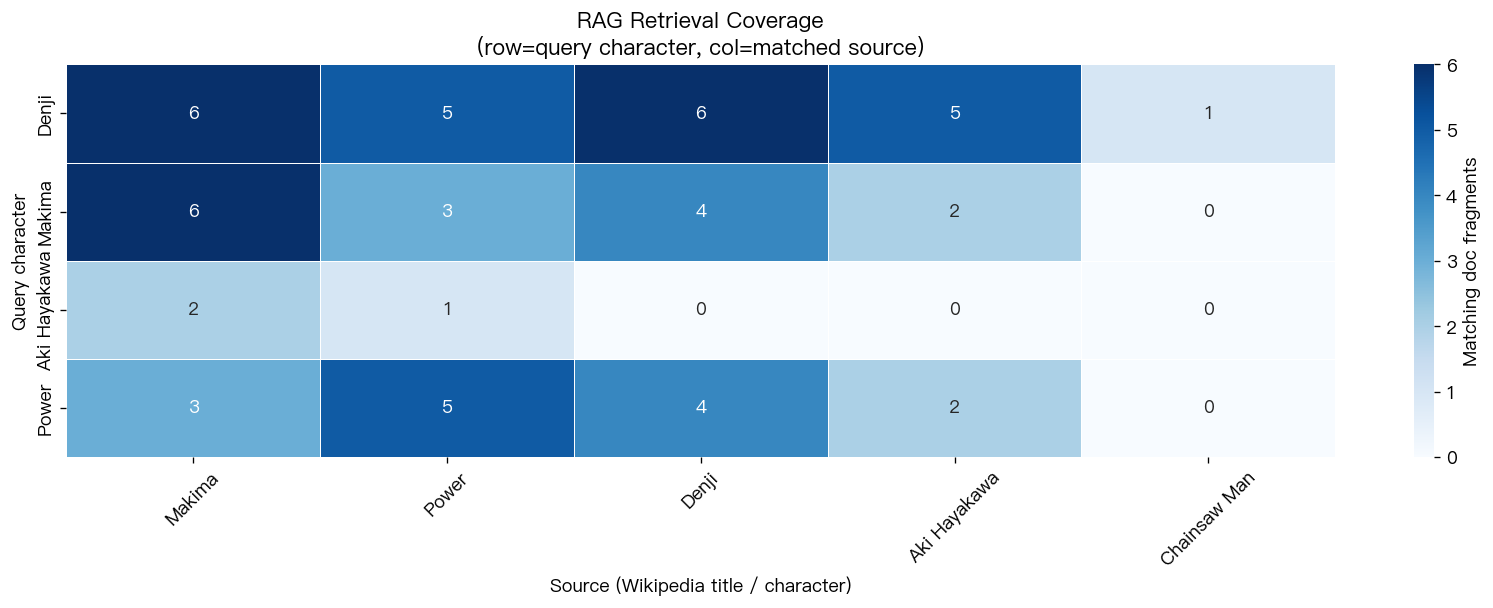

Saved: eval/fig8_retrieval_heatmap.png


In [12]:
# ── Fig 8: Simulated BM25 retrieval coverage per character ────────────────────
# Simulate what keywords are used for retrieval and which characters' docs they hit
char_keywords = {c["name"]: [c["name"].lower(), c.get("role", "").lower()]
                 for c in chars}

retrieval_hits = {}  # {char_query: {source_char: count}}
for query_char in char_keywords:
    hits = Counter()
    query_terms = [t for t in char_keywords[query_char] if t.strip()]
    for d in all_docs:
        text_lower = d["text"].lower()
        score = sum(text_lower.count(term) for term in query_terms if term)
        if score > 0:
            source = d["metadata"].get("character") or d["metadata"].get("title", "?")
            hits[source] += 1
    retrieval_hits[query_char] = hits

# Build retrieval heatmap: rows = query character, cols = source character/title
query_chars  = list(retrieval_hits.keys())
source_chars = sorted(set(
    k for hits in retrieval_hits.values() for k in hits.keys()
), key=lambda x: -sum(retrieval_hits[q].get(x, 0) for q in query_chars))[:12]

ret_matrix = np.array([
    [retrieval_hits[q].get(s, 0) for s in source_chars]
    for q in query_chars
])

fig, ax = plt.subplots(figsize=(14, max(3, len(query_chars) * 0.8 + 2)))
im = sns.heatmap(ret_matrix, ax=ax,
                 xticklabels=source_chars, yticklabels=query_chars,
                 cmap="Blues", annot=True, fmt="d", linewidths=0.5,
                 cbar_kws={"label": "Matching doc fragments"})
ax.set_title("RAG Retrieval Coverage\n(row=query character, col=matched source)")
ax.set_xlabel("Source (Wikipedia title / character)")
ax.set_ylabel("Query character")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig(ROOT / "eval" / "fig8_retrieval_heatmap.png", dpi=130, bbox_inches="tight")
plt.show()
print("Saved: eval/fig8_retrieval_heatmap.png")